In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# Carrega o parquet unificado
df = pd.read_parquet('../data/processed/pede_unified.parquet')

print(f"Shape: {df.shape}")
print(f"Anos: {sorted(df['ano'].unique())}")
df.head()

Shape: (3030, 26)
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


,RA,Fase,Turma,nome,ano_nasc,idade,genero,ano_ingresso,instituicao,iaa,...,ponto_virada,ipv,ian,fase_ideal,defasagem,inde,pedra,ano,data_nasc,ipp
0,RA-1,7,A,Aluno-1,2003.0,19,Menina,2016,Escola Pública,8.3,...,Não,7.278,5.0,Fase 8 (Universitários),-1,5.783,Quartzo,2022,None,NaN
1,RA-2,7,A,Aluno-2,2005.0,17,Menina,2017,Rede Decisão,8.8,...,Não,6.778,10.0,Fase 7 (3º EM),0,7.055,Ametista,2022,None,NaN
2,RA-3,7,A,Aluno-3,2005.0,17,Menina,2016,Rede Decisão,0.0,...,Não,7.556,10.0,Fase 7 (3º EM),0,6.591,Ágata,2022,None,NaN
3,RA-4,7,A,Aluno-4,2005.0,17,Menino,2017,Rede Decisão,8.8,...,Não,5.278,10.0,Fase 7 (3º EM),0,5.951,Quartzo,2022,None,NaN
4,RA-5,7,A,Aluno-5,2005.0,17,Menina,2016,Rede Decisão,7.9,...,Não,7.389,10.0,Fase 7 (3º EM),0,7.427,Ametista,2022,None,NaN


In [2]:
# Visão geral dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RA            3030 non-null   object 
 1   Fase          3030 non-null   int64  
 2   Turma         3030 non-null   object 
 3   nome          3030 non-null   object 
 4   ano_nasc      860 non-null    float64
 5   idade         3030 non-null   int64  
 6   genero        3030 non-null   object 
 7   ano_ingresso  3030 non-null   int64  
 8   instituicao   3029 non-null   object 
 9   iaa           2865 non-null   float64
 10  ieg           2954 non-null   float64
 11  ips           2846 non-null   float64
 12  ida           2852 non-null   float64
 13  nota_mat      2846 non-null   float64
 14  nota_por      2845 non-null   float64
 15  nota_ing      1091 non-null   float64
 16  ponto_virada  860 non-null    object 
 17  ipv           2852 non-null   float64
 18  ian           3030 non-null 

In [3]:
print(df['defasagem'].value_counts().sort_index())
print()
print(df['defasagem'].describe())

defasagem
-5       1
-4       5
-3      39
-2     383
-1    1259
 0    1152
 1     165
 2      24
 3       2
Name: count, dtype: int64

count    3030.000000
mean       -0.642904
std         0.866382
min        -5.000000
25%        -1.000000
50%        -1.000000
75%         0.000000
max         3.000000
Name: defasagem, dtype: float64


## Pergunta 1 — Perfil de defasagem dos alunos

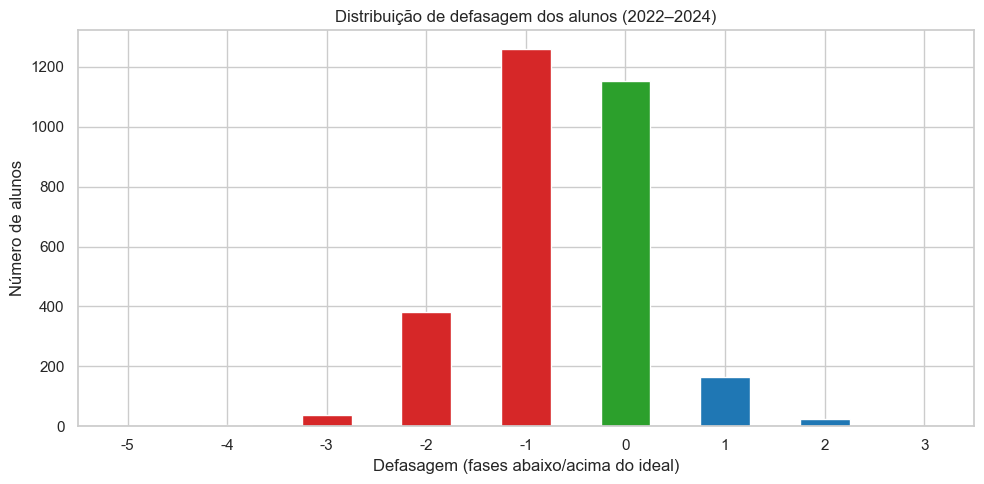

In [4]:
import matplotlib.pyplot as plt

contagem = df['defasagem'].value_counts().sort_index()

cores = ['#d62728' if x < 0 else '#2ca02c' if x == 0 else '#1f77b4' for x in contagem.index]

contagem.plot(kind='bar', color=cores, figsize=(10, 5))
plt.title('Distribuição de defasagem dos alunos (2022–2024)')
plt.xlabel('Defasagem (fases abaixo/acima do ideal)')
plt.ylabel('Número de alunos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Mais de 55% dos alunos apresentam defasagem negativa em relação 
à fase ideal para sua idade, com concentração em -1 fase (1.259 alunos). 
Isso reflete o perfil socioeconômico do público atendido pela Passos Mágicos — 
crianças que chegam ao programa já com atraso escolar acumulado.

## Pergunta 2 — Desempenho acadêmico (IDA) por ano

In [5]:
ida_por_ano = df.groupby('ano')['ida'].mean()
print(ida_por_ano)

ano
2022    6.092907
2023    6.663394
2024    6.364645
Name: ida, dtype: float64


In [6]:
ida_por_fase_ano = df.groupby(['ano', 'Fase'])['ida'].mean().unstack('ano')
print(ida_por_fase_ano.round(2))

ano   2022  2023  2024
Fase                  
0     7.14  7.42  7.34
1     6.46  6.81  6.81
2     5.41  6.74  6.28
3     5.14  5.75  5.35
4     6.05  6.00  5.88
5     5.87  5.90  6.46
6     6.69  6.81  7.23
7     5.25  7.81  5.82
8      NaN   NaN  8.00
9      NaN   NaN   NaN


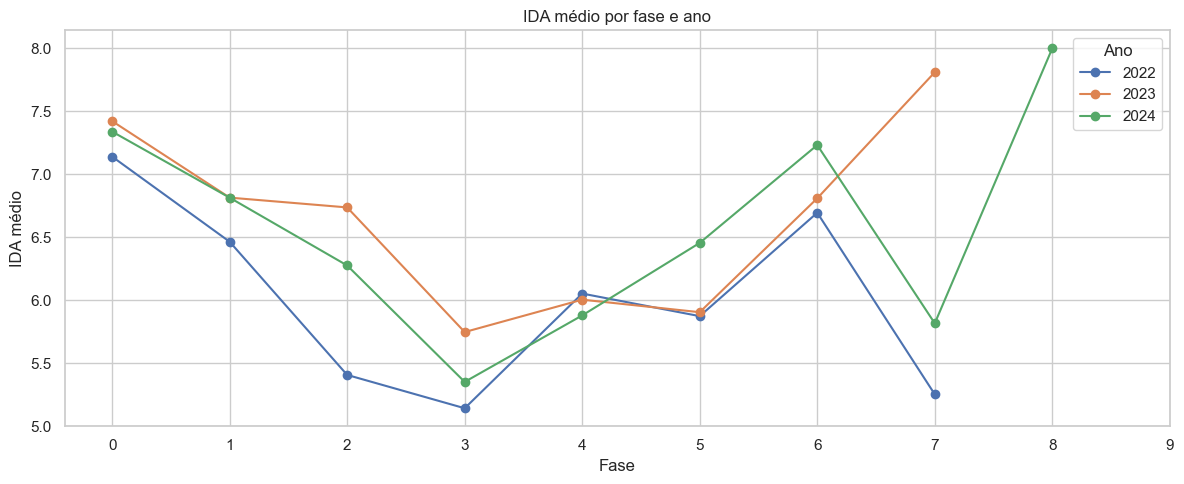

In [7]:
import matplotlib.pyplot as plt

ax = ida_por_fase_ano.plot(
    kind='line', marker='o', figsize=(12, 5)
)
plt.title('IDA médio por fase e ano')
plt.xlabel('Fase')
plt.ylabel('IDA médio')
plt.legend(title='Ano')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

**Insight:** O IDA não segue uma tendência linear — há um vale pronunciado na 
Fase 3 em todos os anos, sugerindo que essa é uma fase crítica de transição. 
A Fase 7 apresenta alta volatilidade entre anos. As fases iniciais (0 e 1) 
e avançadas (6, 7, 8) tendem a ter melhor desempenho, possivelmente pela 
maior maturidade dos alunos nas fases superiores e pelo suporte intensivo 
nas fases iniciais.

 Pergunta 3 — Engajamento (IEG) vs Desempenho (IDA).

In [8]:
correlacao = df[['ieg', 'ida', 'iaa', 'ips', 'ipp', 'ipv', 'ian', 'inde']].corr()
print(correlacao['inde'].sort_values(ascending=False).round(3))


inde    1.000
ida     0.785
ieg     0.745
ipv     0.721
ipp     0.540
ian     0.405
iaa     0.397
ips     0.200
Name: inde, dtype: float64


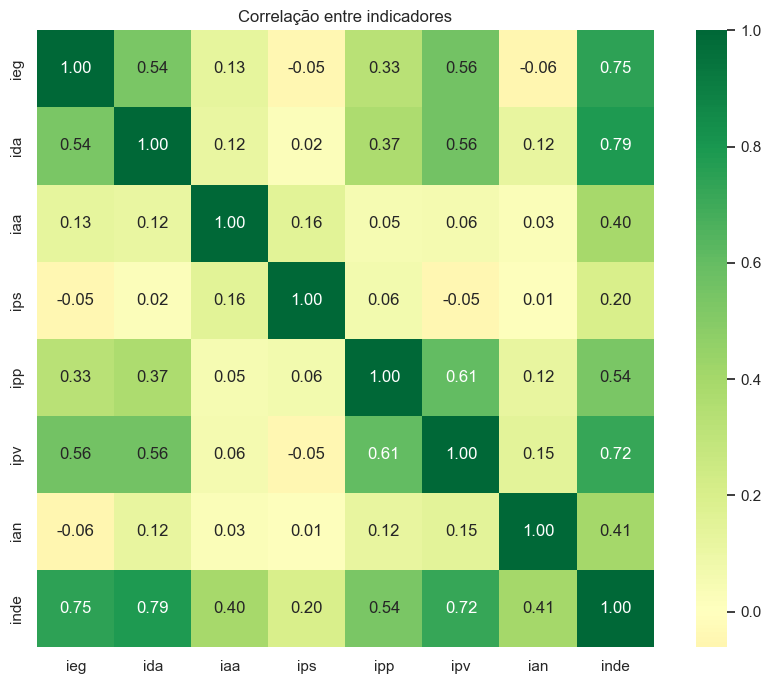

In [9]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    ax=ax
)

plt.title('Correlação entre indicadores')
plt.tight_layout()
plt.show()

In [10]:
df_valido = df[['iaa', 'ida']].dropna()

superestimacao = (df_valido['iaa'] > df_valido['ida']).sum()
subestimacao = (df_valido['iaa'] < df_valido['ida']).sum()
preciso = (df_valido['iaa'] == df_valido['ida']).sum()

total = len(df_valido)
print(f"Superestimam o próprio desempenho: {superestimacao} ({superestimacao/total:.1%})")
print(f"Subestimam o próprio desempenho:   {subestimacao} ({subestimacao/total:.1%})")
print(f"Avaliação precisa:                  {preciso} ({preciso/total:.1%})")

Superestimam o próprio desempenho: 2250 (78.9%)
Subestimam o próprio desempenho:   548 (19.2%)
Avaliação precisa:                  53 (1.9%)


**Insight:** 78,9% dos alunos superestimam seu próprio desempenho. 
Isso pode refletir uma estratégia pedagógica intencional do programa — 
cultivar autoconfiança como precursor do desenvolvimento acadêmico. 
A baixa correlação entre IAA e IDA (0.12) sugere que autoestima e 
desempenho evoluem em ritmos diferentes.